# Day 06 — Project: NBA

Priya, an editor at a sports-media outlet, emails you six weeks before opening night: she's chasing a season-preview feature and needs numbers to back it up. Attached is `nba.sqlite` — the league's full historical record, no cleanup done. Her question list reads more like a reporter thinking out loud than a spec sheet. This notebook works through all twenty of them, in the order she asked.

No new SQL syntax today — everything here is Days 01-04 (filtering, aggregation, JOINs, GROUP BY/HAVING, anti-joins) applied to a real, 16-table dataset that wasn't built with these exact questions in mind, run through jupysql's `%%sql` magic from Day 05. See `day06_reading.html` for the full brief and where the dataset comes from.

## Getting connected

In [1]:
%load_ext sql

In [2]:
%sql sqlite:///nba.sqlite --alias nba

Connecting to 'nba'

A bare connection string, no SQLAlchemy needed — the same Option 2 pattern `day05_python_sqlite.ipynb` used for SQLite.

In [3]:
%%sql
SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;

Running query in 'nba'

name
common_player_info
draft_combine_stats
draft_history
game
game_info
game_summary
inactive_players
line_score
officials
other_stats


16 tables — more than any prior day's dataset. A quick preview of each before diving into Priya's questions, looping a `%sql` line-magic call per table with jupysql's `{{ }}` templating:

In [4]:
from IPython.display import Markdown, display

tables_result = %sql SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
table_names = tables_result.DataFrame()['name'].tolist()

for table in table_names:
    display(Markdown(f"### {table}"))
    preview = %sql SELECT * FROM {{table}} LIMIT 3
    display(preview)

Running query in 'nba'

### common_player_info

Running query in 'nba'

person_id,first_name,last_name,display_first_last,display_last_comma_first,display_fi_last,player_slug,birthdate,school,country,last_affiliation,height,weight,season_exp,jersey,position,rosterstatus,games_played_current_season_flag,team_id,team_name,team_abbreviation,team_code,team_city,playercode,from_year,to_year,dleague_flag,nba_flag,games_played_flag,draft_year,draft_round,draft_number,greatest_75_flag
76001,Alaa,Abdelnaby,Alaa Abdelnaby,"Abdelnaby, Alaa",A. Abdelnaby,alaa-abdelnaby,1968-06-24 00:00:00,Duke,USA,Duke/USA,6-10,240,5.0,30,Forward,Inactive,N,1610612757,Trail Blazers,POR,blazers,Portland,HISTADD_alaa_abdelnaby,1990.0,1994.0,N,Y,Y,1990,1,25,N
76002,Zaid,Abdul-Aziz,Zaid Abdul-Aziz,"Abdul-Aziz, Zaid",Z. Abdul-Aziz,zaid-abdul-aziz,1946-04-07 00:00:00,Iowa State,USA,Iowa State/USA,6-9,235,10.0,54,Center,Inactive,N,1610612745,Rockets,HOU,rockets,Houston,HISTADD_zaid_abdul-aziz,1968.0,1977.0,N,Y,Y,1968,1,5,N
76003,Kareem,Abdul-Jabbar,Kareem Abdul-Jabbar,"Abdul-Jabbar, Kareem",K. Abdul-Jabbar,kareem-abdul-jabbar,1947-04-16 00:00:00,UCLA,USA,UCLA/USA,7-2,225,20.0,33,Center,Inactive,N,1610612747,Lakers,LAL,lakers,Los Angeles,HISTADD_kareem_abdul-jabbar,1969.0,1988.0,N,Y,Y,1969,1,1,Y


### draft_combine_stats

...

Running query in 'nba'

team_id,city,nickname,year_founded,year_active_till
1610612737,Atlanta,Hawks,1968,2019
1610612737,St. Louis,Hawks,1955,1967
1610612737,Milwaukee,Hawks,1951,1954


### team_info_common

Running query in 'nba'

team_id,season_year,team_city,team_name,team_abbreviation,team_conference,team_division,team_code,team_slug,w,l,pct,conf_rank,div_rank,min_year,max_year,league_id,season_id,pts_rank,pts_pg,reb_rank,reb_pg,ast_rank,ast_pg,opp_pts_rank,opp_pts_pg


---

Priya opens with the draft itself.

### Q1 — How has the number of players drafted per year changed, 1949-2020?

**Business question:** the feature opens with a draft-history timeline — did the draft get bigger or smaller over the decades?

In [5]:
%%sql draft_by_year_result  <<
SELECT season, COUNT(person_id) AS players_drafted
FROM draft_history
WHERE draft_type = 'Draft'
  AND season BETWEEN '1949' AND '2020'
GROUP BY season
ORDER BY season

Running query in 'nba'

<Axes: title={'center': 'Players drafted per year, 1949-2020'}, xlabel='season'>

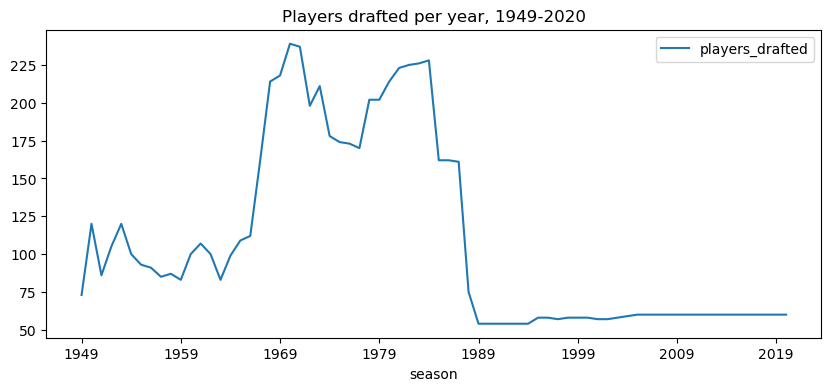

In [6]:
draft_by_year = draft_by_year_result.DataFrame()
draft_by_year.plot(x="season", y="players_drafted", kind="line", figsize=(10, 4),
                    title="Players drafted per year, 1949-2020")

**Insight:** the draft ballooned past 200 picks a year through the 1970s-80s (multiple rounds, plus a wave of expansion teams), then dropped to a steady ~54-60 picks/year once the NBA capped it at two rounds starting with the 1989 draft.

### Q2 — How old are drafted players on average, and has that changed by decade?

**Business question:** Priya keeps hearing about the "one-and-done" era — is the data behind that as clear as the narrative?

In [7]:
%%sql age_by_decade_result  <<
SELECT (CAST(draft_year AS INT) / 10) * 10 AS decade,
       ROUND(AVG(CAST(draft_year AS INT) - CAST(STRFTIME('%Y', birthdate) AS INT)), 1) AS avg_age_at_draft,
       COUNT(*) AS n
FROM common_player_info
WHERE draft_year IS NOT NULL AND draft_year != 'Undrafted' AND birthdate IS NOT NULL
GROUP BY decade
ORDER BY decade

Running query in 'nba'

,decade,avg_age_at_draft,n
0,1940,24.3,86
1,1950,23.1,186
2,1960,22.3,243
3,1970,22.4,424
4,1980,22.3,458
5,1990,22.2,359
6,2000,21.4,363
7,2010,21.3,446
8,2020,20.5,136


<Axes: title={'center': 'Average age at draft, by decade'}, xlabel='decade'>

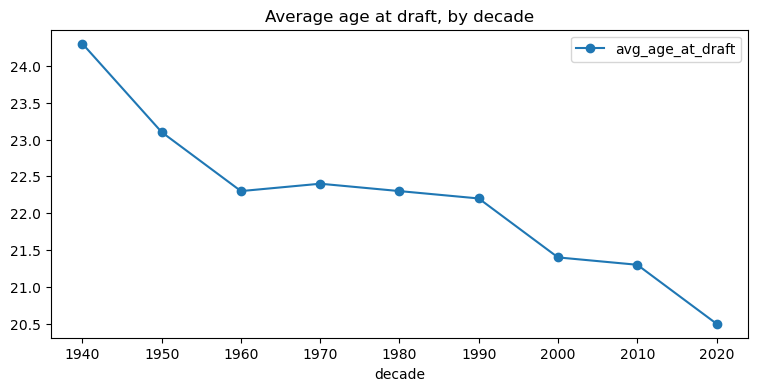

In [8]:
age_by_decade = age_by_decade_result.DataFrame()
display(age_by_decade)
age_by_decade.plot(x="decade", y="avg_age_at_draft", kind="line", figsize=(9, 4), marker="o",
                    title="Average age at draft, by decade")

**Insight:** average draft age has fallen steadily, from 24.3 in the 1940s to 20.5 in the 2020s — the "one-and-done" narrative holds up, and it's not a recent blip, it's a decades-long trend.

### Q3 — Which 10 teams have drafted the most players out of college/university?

**Business question:** a "college pipeline" sidebar — which franchises lean hardest on university talent?

In [9]:
%%sql top_university_teams_result  <<
SELECT team_name, COUNT(person_id) AS players_drafted
FROM draft_history
WHERE organization_type LIKE '%University%'
GROUP BY team_name
ORDER BY players_drafted DESC
LIMIT 10

Running query in 'nba'

,team_name,players_drafted
0,Knicks,488
1,Hawks,475
2,Celtics,459
3,Warriors,457
4,Pistons,435
5,Lakers,433
6,Bullets,428
7,76ers,348
8,Bulls,335
9,Royals,301


<Axes: title={'center': 'Most players drafted from college/university, by team'}, ylabel='team_name'>

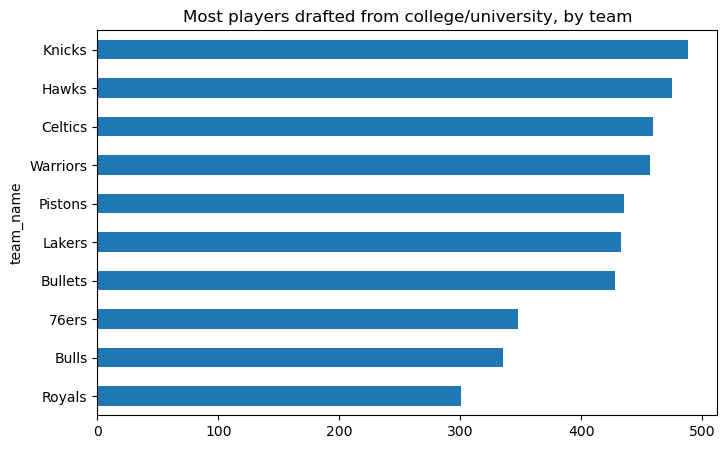

In [10]:
top_university_teams = top_university_teams_result.DataFrame()
display(top_university_teams)
top_university_teams.sort_values("players_drafted").plot(
    x="team_name", y="players_drafted", kind="barh", figsize=(8, 5), legend=False,
    title="Most players drafted from college/university, by team")

**Insight:** the Knicks (488), Hawks (475), and Celtics (459) top the list — unsurprising, since these are three of the league's oldest continuously-operating franchises, so they've simply had more draft classes to accumulate picks in.

### Q4 — Where do drafted players come from overall: high school, university, or another pro club?

**Business question:** a quick stat box for the sidebar — how dominant is the college pathway, really?

In [11]:
%%sql org_type_result  <<
SELECT organization_type, COUNT(*) AS players_drafted
FROM draft_history
GROUP BY organization_type
ORDER BY players_drafted DESC

Running query in 'nba'

,organization_type,players_drafted
0,College/University,7848
1,Other Team/Club,340
2,High School,49
3,,20


<Axes: title={'center': 'Drafted players by source'}>

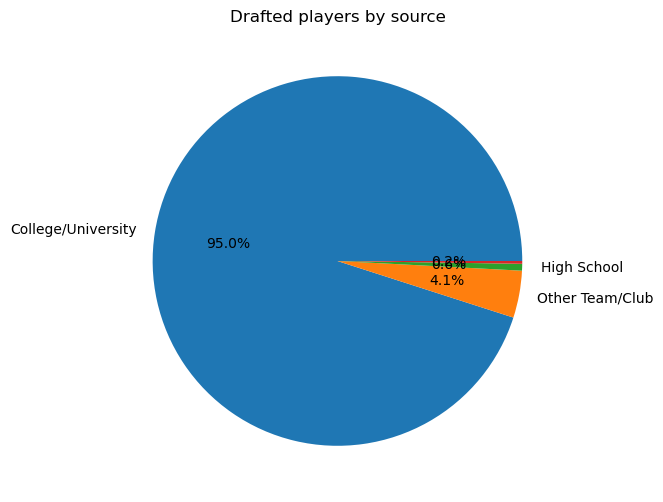

In [12]:
org_type_breakdown = org_type_result.DataFrame()
display(org_type_breakdown)
org_type_breakdown.set_index("organization_type")["players_drafted"].plot(
    kind="pie", autopct="%1.1f%%", ylabel="", figsize=(6, 6),
    title="Drafted players by source")

**Insight:** College/University accounts for 7,848 of roughly 8,257 draft picks on record (~95%) — high schoolers (49, before the league banned prep-to-pro picks in 2006) and players drafted straight from another pro club (340, mostly international) are both minor pathways by comparison.

### Q5 — When did teams first start drafting players out of college/university?

**Business question:** Priya wants a single "since [year]" fact to anchor the sidebar's opening line.

In [13]:
%%sql
SELECT MIN(season) AS first_university_draft
FROM draft_history
WHERE organization_type = 'College/University';

Running query in 'nba'

first_university_draft
1947


**Insight:** 1947 — essentially as far back as this dataset's draft records go, so the college pipeline isn't a modern trend, it's been the primary pathway since the league's earliest years.

Then she pivots from the draft to the league's own history.

### Q6 — From 1949 to 2020, how did the number of teams playing and the number of games played change together?

**Business question:** a "growth of the league" chart — team-count expansion and schedule growth on the same timeline.

In [14]:
%%sql league_growth_result  <<
SELECT STRFTIME('%Y', game_date) AS calendar_year,
       COUNT(DISTINCT team_id_home) AS teams_playing,
       COUNT(*) AS games_played
FROM game
WHERE STRFTIME('%Y', game_date) BETWEEN '1949' AND '2020'
GROUP BY calendar_year
ORDER BY calendar_year

Running query in 'nba'

array([<Axes: xlabel='calendar_year'>, <Axes: xlabel='calendar_year'>],
      dtype=object)

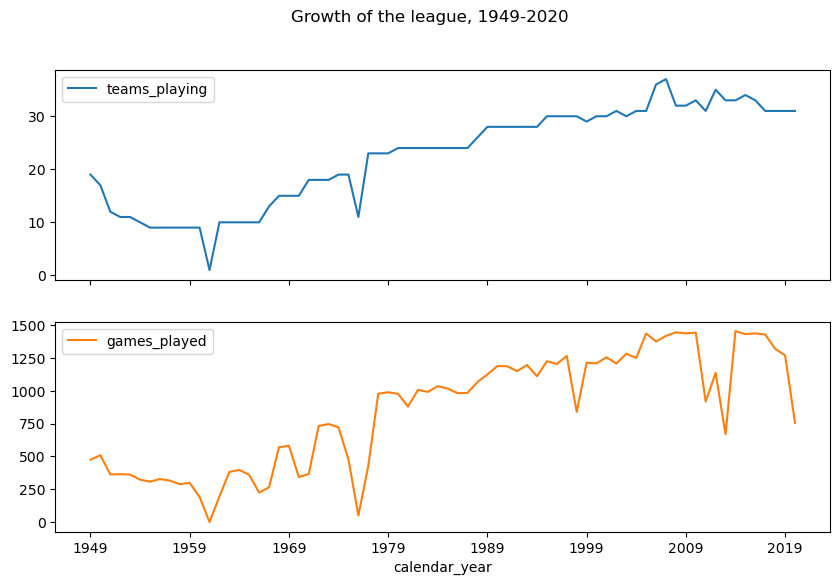

In [15]:
league_growth = league_growth_result.DataFrame()
league_growth.plot(x="calendar_year", y=["teams_playing", "games_played"], subplots=True,
                    figsize=(10, 6), title="Growth of the league, 1949-2020")

**Insight:** team count climbs from 17-19 in the late 1940s to a modern high of 30 — but a few recent years show 31-33 "teams," not because the NBA expanded past 30. `game_date` is a calendar date, not a season, so a single season straddles two calendar years at its boundary, and some rows are preseason exhibition games against non-NBA clubs (FC Barcelona, Real Madrid) or All-Star games. Real lesson: always sanity-check a "distinct team count" against what you know the league actually looked like before publishing it — a JOIN to `team` later on revisits this cleanly.

### Q7 — How has the home-court win rate changed over time?

**Business question:** "home-court advantage" is a classic sports storyline — is it still as strong as it used to be?

In [16]:
%%sql home_win_by_decade_result  <<
SELECT (CAST(STRFTIME('%Y', game_date) AS INT) / 10) * 10 AS decade,
       ROUND(SUM(CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS home_win_pct,
       COUNT(*) AS games
FROM game
WHERE game_date IS NOT NULL
GROUP BY decade
ORDER BY decade

Running query in 'nba'

<Axes: title={'center': 'Home-court win rate by decade'}, xlabel='decade'>

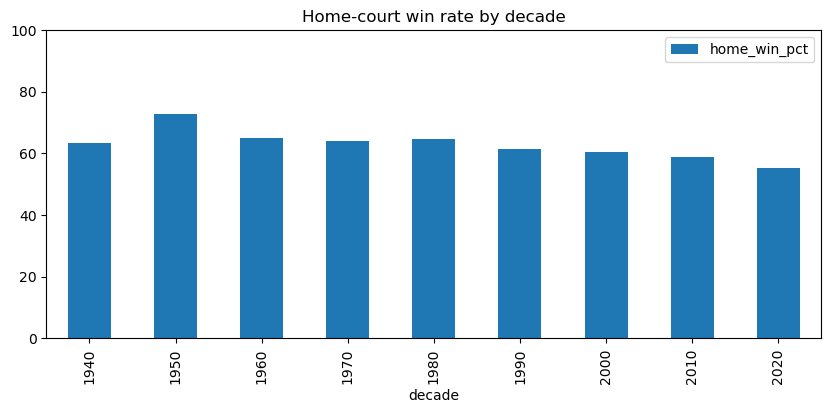

In [17]:
home_win_by_decade = home_win_by_decade_result.DataFrame()
home_win_by_decade.plot(x="decade", y="home_win_pct", kind="bar", figsize=(10, 4),
                         title="Home-court win rate by decade", ylim=(0, 100))

**Insight:** home-court advantage has been eroding for 70 years straight — from 72.7% in the 1950s down to 55.3% in the 2020s so far. Better travel/recovery, more player movement, and (in recent years) empty-arena COVID seasons are all plausible contributors — worth a follow-up question for Priya rather than a single-cause claim.

### Q8 — Has the overtime rate changed over time?

**Business question:** a companion stat to home-court advantage — are games getting closer, or does it just feel that way?

In [18]:
%%sql ot_by_decade_result  <<
SELECT (CAST(STRFTIME('%Y', g.game_date) AS INT) / 10) * 10 AS decade,
       ROUND(SUM(CASE WHEN ls.pts_ot1_home > 0 OR ls.pts_ot1_away > 0 THEN 1 ELSE 0 END) * 100.0
             / COUNT(*), 2) AS ot_pct,
       COUNT(*) AS games
FROM game g
LEFT JOIN line_score ls ON g.game_id = ls.game_id
WHERE g.game_date IS NOT NULL
GROUP BY decade
ORDER BY decade

Running query in 'nba'

,decade,ot_pct,games
0,1940,2.95,1187
1,1950,5.69,3480
2,1960,3.90,3177
3,1970,4.03,5838
4,1980,4.71,10063
5,1990,5.15,11581
6,2000,5.53,13317
7,2010,5.41,12507
8,2020,4.84,4628


<Axes: title={'center': 'Overtime rate by decade'}, xlabel='decade'>

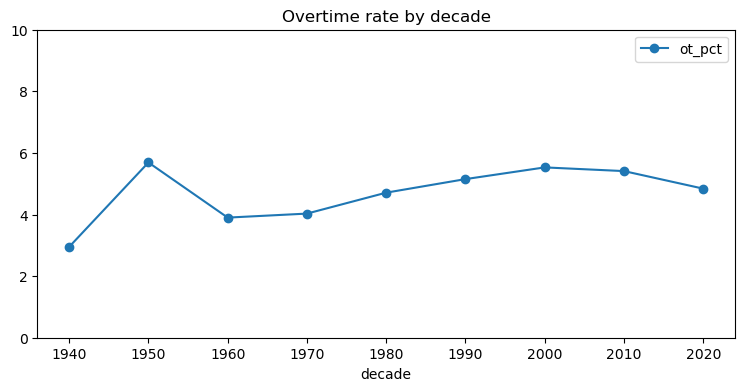

In [19]:
ot_by_decade = ot_by_decade_result.DataFrame()
display(ot_by_decade)
ot_by_decade.plot(x="decade", y="ot_pct", kind="line", marker="o", figsize=(9, 4),
                   title="Overtime rate by decade", ylim=(0, 10))

**Insight:** a real trap worth naming. The first version of this query checked `pts_ot1_home IS NOT NULL` and came back with an absurd ~90% OT rate from the 2000s on — because in that era the column is populated with `0` for every game, OT or not, while older rows leave it genuinely blank. Checking `> 0` instead of `IS NOT NULL` fixes it: the real OT rate has held steady at roughly 4-5.5% across every decade since the 1950s. Same lesson as Q6 — a surprising number is a prompt to check your assumptions, not a fact to hand Priya.

### Q9 — Which months carry the heaviest game load?

**Business question:** helps Priya's scheduling sidebar explain why national broadcasters cluster marquee games in certain months.

In [20]:
%%sql games_by_month_result  <<
SELECT STRFTIME('%m', game_date) AS month, COUNT(game_id) AS games_cnt
FROM game
GROUP BY month
ORDER BY games_cnt DESC

Running query in 'nba'

,month,games_cnt
0,03,11269
1,01,11246
2,12,10587
3,11,10125
4,02,9840
5,04,7077
6,10,3403
7,05,1698
8,06,275
9,08,122


<Axes: title={'center': 'Games played per month (all-time)'}, xlabel='month'>

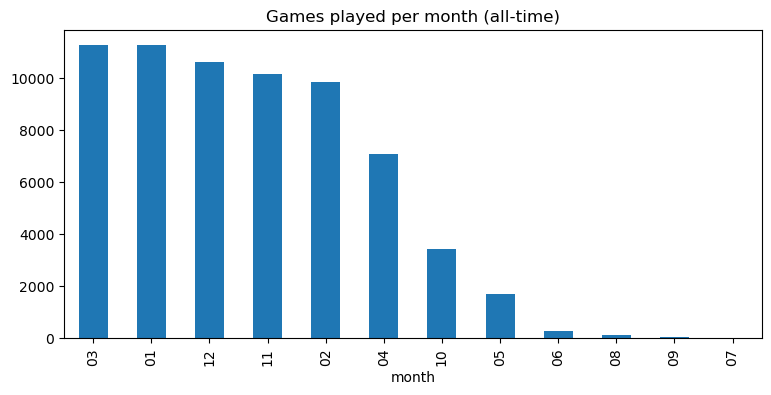

In [21]:
games_by_month = games_by_month_result.DataFrame()
display(games_by_month)
games_by_month.plot(x="month", y="games_cnt", kind="bar", figsize=(9, 4), legend=False,
                     title="Games played per month (all-time)")

**Insight:** March, January, and December are the heaviest months (10,500-11,300 games each) — the heart of the regular season. July and September barely register, since that's the offseason; June is mostly Finals games, which is why it's so much lighter than the regular-season months.

### Q10 — How has average attendance changed by decade?

**Business question:** attendance trend is a natural companion chart to the home-win-rate chart from Q7.

In [22]:
%%sql attendance_by_decade_result  <<
SELECT (CAST(STRFTIME('%Y', game_date) AS INT) / 10) * 10 AS decade,
       ROUND(AVG(attendance)) AS avg_attendance,
       COUNT(*) AS games_with_data
FROM game_info
WHERE attendance IS NOT NULL
GROUP BY decade
ORDER BY decade

Running query in 'nba'

,decade,avg_attendance,games_with_data
0,1940,6712.0,13
1,1950,5520.0,55
2,1960,7005.0,2307
3,1970,10068.0,4915
4,1980,12100.0,8577
5,1990,16521.0,10225
6,2000,17266.0,11789
7,2010,17536.0,11376
8,2020,15650.0,3416


<Axes: title={'center': 'Average attendance by decade'}, xlabel='decade'>

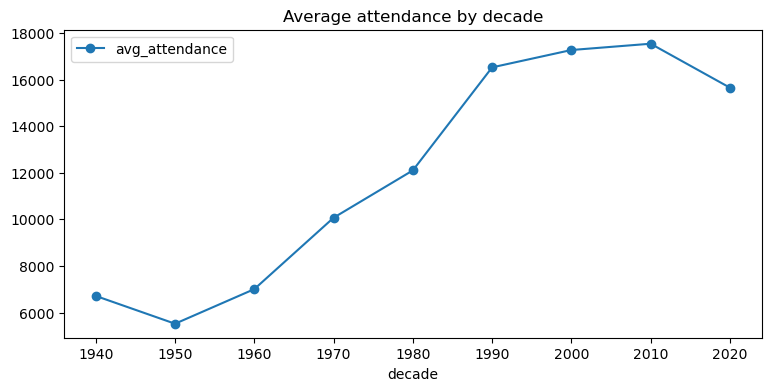

In [23]:
attendance_by_decade = attendance_by_decade_result.DataFrame()
display(attendance_by_decade)
attendance_by_decade.plot(x="decade", y="avg_attendance", kind="line", marker="o", figsize=(9, 4),
                           title="Average attendance by decade")

**Insight:** average attendance climbed steadily from ~6,700 in the 1940s to ~16,500 by the 1990s. Worth flagging for Priya: only 52,673 of 58,053 games (~91%) have recorded attendance at all, and the gap is concentrated in the earliest decades (13 games total in the 1940s vs. thousands per decade later on) — the early trend is thin data, not a settled fact.

### Q11 — What are the biggest home blowouts on record?

**Business question:** a "greatest blowouts" callout box — always a reader favorite.

In [24]:
%%sql
SELECT game_date, team_name_home, team_name_away, pts_home, pts_away,
       (pts_home - pts_away) AS margin
FROM game
WHERE pts_home IS NOT NULL AND pts_away IS NOT NULL
ORDER BY margin DESC
LIMIT 5;

Running query in 'nba'

game_date,team_name_home,team_name_away,pts_home,pts_away,margin
2021-12-02 00:00:00,Memphis Grizzlies,Oklahoma City Thunder,152.0,79.0,73.0
1991-12-17 00:00:00,Cleveland Cavaliers,Miami Heat,148.0,80.0,68.0
1998-02-27 00:00:00,Indiana Pacers,Portland Trail Blazers,124.0,59.0,65.0
1972-03-19 00:00:00,Los Angeles Lakers,Golden State Warriors,162.0,99.0,63.0
1991-11-02 00:00:00,Golden State Warriors,Sacramento Kings,153.0,91.0,62.0


**Insight:** the Grizzlies' 152-79 win over the Thunder (Dec 2, 2021 — a 73-point margin) tops the list, ahead of a 68-point Cavaliers rout of the Heat from 1991. Blowouts of this size show up in every era, not just recent ones.

A few "did-you-know" asides for sidebars — Priya wants player-profile trivia next.

### Q12 — Does average wingspan differ by position?

**Business question:** a scouting-department sidebar comparing measurable athleticism across positions.

In [25]:
%%sql wingspan_by_position_result  <<
SELECT position, ROUND(AVG(wingspan), 1) AS avg_wingspan, COUNT(*) AS n
FROM draft_combine_stats
WHERE wingspan IS NOT NULL AND position IS NOT NULL AND position != ''
GROUP BY position
ORDER BY avg_wingspan DESC

Running query in 'nba'

,position,avg_wingspan,n
0,C,87.8,125
1,C-PF,86.3,62
2,PF-C,86.2,80
3,PF,85.0,276
4,PF-SF,84.6,55
5,SF-PF,84.2,59
6,SF,82.9,186
7,SF-SG,82.2,48
8,SG-SF,81.6,92
9,SG,80.5,234


<Axes: title={'center': 'Average combine wingspan by position (inches)'}, ylabel='position'>

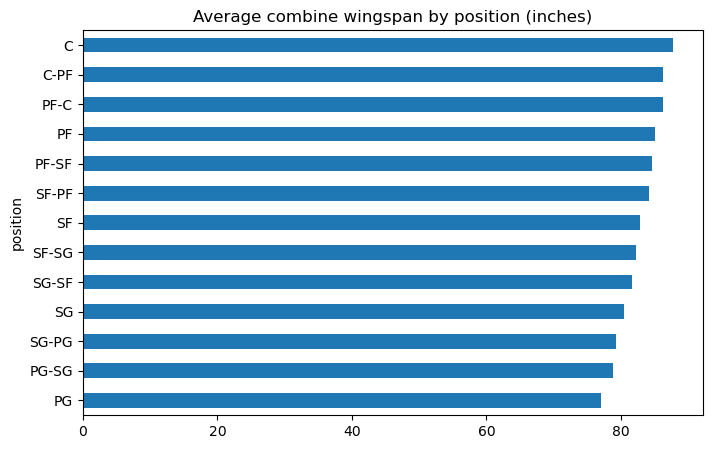

In [26]:
wingspan_by_position = wingspan_by_position_result.DataFrame()
display(wingspan_by_position)
wingspan_by_position.sort_values("avg_wingspan").plot(
    x="position", y="avg_wingspan", kind="barh", figsize=(8, 5), legend=False,
    title="Average combine wingspan by position (inches)")

**Insight:** Centers average the longest wingspan (87.8"), tapering down through forward and combo-forward positions — exactly the physical profile you'd expect for a position built around rim protection and rebounding.

### Q13 — Has the average height of drafted players changed over time?

**Business question:** "the league is getting smaller and more skill-based" is a common take — does the data back it up?

In [27]:
%%sql height_by_decade_result  <<
SELECT (CAST(draft_year AS INT) / 10) * 10 AS decade,
       ROUND(AVG(CAST(SUBSTR(height, 1, INSTR(height, '-') - 1) AS INT) * 12
             + CAST(SUBSTR(height, INSTR(height, '-') + 1) AS INT)), 1) AS avg_height_in,
       COUNT(*) AS n
FROM common_player_info
WHERE height IS NOT NULL AND height != '' AND draft_year IS NOT NULL AND draft_year != 'Undrafted'
GROUP BY decade
ORDER BY decade

Running query in 'nba'

,decade,avg_height_in,n
0,1940,74.8,83
1,1950,76.7,185
2,1960,77.5,243
3,1970,78.0,424
4,1980,78.8,445
5,1990,79.2,340
6,2000,79.3,354
7,2010,78.8,443
8,2020,78.3,136


<Axes: title={'center': 'Average height of drafted players, by decade'}, xlabel='decade'>

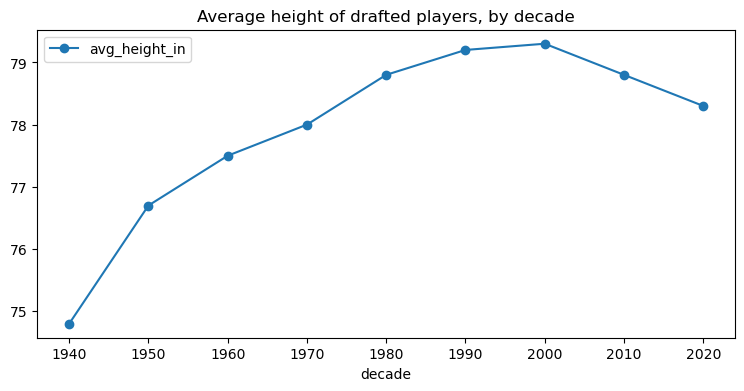

In [28]:
height_by_decade = height_by_decade_result.DataFrame()
display(height_by_decade)
height_by_decade.plot(x="decade", y="avg_height_in", kind="line", marker="o", figsize=(9, 4),
                       title="Average height of drafted players, by decade")

**Insight:** `height` is stored as text like `6-10` (feet-inches), so getting a number out of it needs `SUBSTR`/`INSTR` — the same string-parsing move from Day 03. Average height rose from 74.8" in the 1940s to a peak of 79.3" in the 2000s, then eased back to 78.3" in the 2020s — the "smaller, skill-based league" take is real, but only for the last decade; height climbed for the 60 years before that.

The rest of Priya's list needs more digging — franchise-level questions that only resolve once they're joined against `team`.

### Q14 — Which current franchises have drafted the most players overall?

**Business question:** Q3 only looked at university picks — Priya also wants the *all-time* leaderboard across every draft type and source.

In [29]:
%%sql top_franchises_result  <<
SELECT t.full_name, COUNT(*) AS players_drafted
FROM draft_history d
JOIN team t ON d.team_id = t.id
GROUP BY t.full_name
ORDER BY players_drafted DESC
LIMIT 10

Running query in 'nba'

,full_name,players_drafted
0,Sacramento Kings,530
1,Atlanta Hawks,520
2,New York Knicks,502
3,Philadelphia 76ers,496
4,Boston Celtics,473
5,Golden State Warriors,471
6,Detroit Pistons,449
7,Los Angeles Lakers,444
8,Washington Wizards,419
9,Chicago Bulls,344


<Axes: title={'center': 'Most players drafted overall, by current franchise'}, ylabel='full_name'>

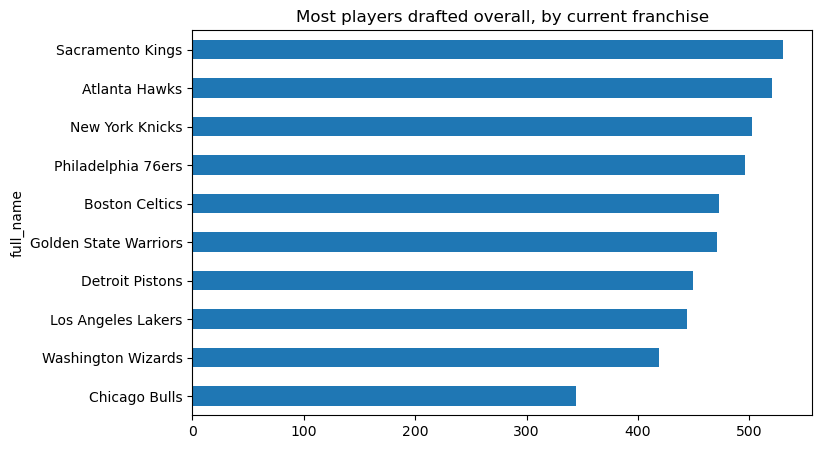

In [30]:
top_franchises_drafted = top_franchises_result.DataFrame()
display(top_franchises_drafted)
top_franchises_drafted.sort_values("players_drafted").plot(
    x="full_name", y="players_drafted", kind="barh", figsize=(8, 5), legend=False,
    title="Most players drafted overall, by current franchise")

**Insight:** joining to `team` (instead of using `draft_history`'s own `team_name` column) resolves every historical pick to today's franchise name and merges relocated/renamed teams into one row — the Sacramento Kings lead at 530, once every Rochester Royals/Cincinnati Royals/Kansas City Kings pick is correctly counted as the same franchise (see Q18).

### Q15 — Which teams have won the most home games, and who currently runs their franchise?

**Business question:** Priya wants the win-total leaderboard paired with each team's current arena and head coach for the photo captions.

In [31]:
%%sql
SELECT td.headcoach, td.arena, wins.home_wins
FROM (
    SELECT team_id_home, COUNT(*) AS home_wins
    FROM game
    WHERE wl_home = 'W'
    GROUP BY team_id_home
    ORDER BY home_wins DESC
    LIMIT 5
) wins
JOIN team_details td ON wins.team_id_home = td.team_id;

Running query in 'nba'

headcoach,arena,home_wins
Darvin Ham,Crypto.com Arena,2211
Joe Mazzulla,TD Garden,2200
Nick Nurse,Wells Fargo Center,1861
Quin Snyder,State Farm Arena,1827
Steve Kerr,Chase Center,1824


**Insight:** `team_details` only has current-day info (arena, coach, GM), so the aggregation has to happen first, in a derived table, before joining — joining first would repeat that lookup once per underlying game row for no benefit. Same pattern as Day 03's JOIN + GROUP BY section, just with the GROUP BY resolved before the JOIN instead of after.

### Q16 — Which teams currently have the most international players on their roster?

**Business question:** a "global game" sidebar — which franchises have built the most internationally-diverse roster?

In [32]:
%%sql international_roster_result  <<
SELECT t.full_name, COUNT(*) AS international_players
FROM common_player_info c
JOIN team t ON c.team_id = t.id
WHERE c.country != 'USA' AND c.rosterstatus = 'Active'
GROUP BY t.full_name
ORDER BY international_players DESC
LIMIT 8

Running query in 'nba'

,full_name,international_players
0,Dallas Mavericks,7
1,Utah Jazz,5
2,Toronto Raptors,5
3,Sacramento Kings,5
4,Phoenix Suns,5
5,Oklahoma City Thunder,5
6,Indiana Pacers,5
7,San Antonio Spurs,4


<Axes: title={'center': 'Most international players on an active roster, today'}, ylabel='full_name'>

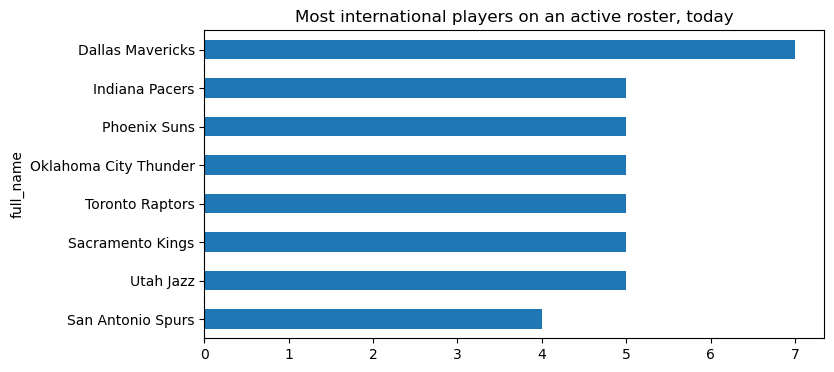

In [33]:
international_roster = international_roster_result.DataFrame()
display(international_roster)
international_roster.sort_values("international_players").plot(
    x="full_name", y="international_players", kind="barh", figsize=(8, 4), legend=False,
    title="Most international players on an active roster, today")

**Insight:** the Mavericks lead with 7 international players on their active roster, with Utah, Toronto, Sacramento, Phoenix, and Oklahoma City close behind at 5 each — international scouting is spread across small-, mid-, and large-market teams alike, not concentrated in one region.

### Q17 — Which currently-active franchises are the oldest?

**Business question:** a "league roots" trivia box for the sidebar.

In [34]:
%%sql
SELECT full_name, year_founded
FROM team
ORDER BY year_founded ASC
LIMIT 8;

Running query in 'nba'

full_name,year_founded
Boston Celtics,1946.0
Golden State Warriors,1946.0
New York Knicks,1946.0
Los Angeles Lakers,1948.0
Sacramento Kings,1948.0
Detroit Pistons,1948.0
Atlanta Hawks,1949.0
Philadelphia 76ers,1949.0


**Insight:** the Celtics, Warriors, and Knicks all trace back to 1946, the league's founding year as the BAA — three of the four oldest teams on this list are still in their original city, unlike the Kings a few questions from now.

### Q18 — Which franchises have changed city or nickname the most?

**Business question:** a "franchise history" trivia box — some teams have been rebranded or relocated far more than others.

In [35]:
%%sql relocation_count_result  <<
SELECT t.full_name, COUNT(*) AS city_or_name_eras
FROM team_history th
JOIN team t ON th.team_id = t.id
GROUP BY t.full_name
ORDER BY city_or_name_eras DESC
LIMIT 8

Running query in 'nba'

,full_name,city_or_name_eras
0,Sacramento Kings,5
1,New Orleans Pelicans,4
2,Atlanta Hawks,4
3,Los Angeles Clippers,3
4,Golden State Warriors,3
5,Brooklyn Nets,3
6,Utah Jazz,2
7,Philadelphia 76ers,2


<Axes: title={'center': 'Most city/nickname eras, by current franchise'}, ylabel='full_name'>

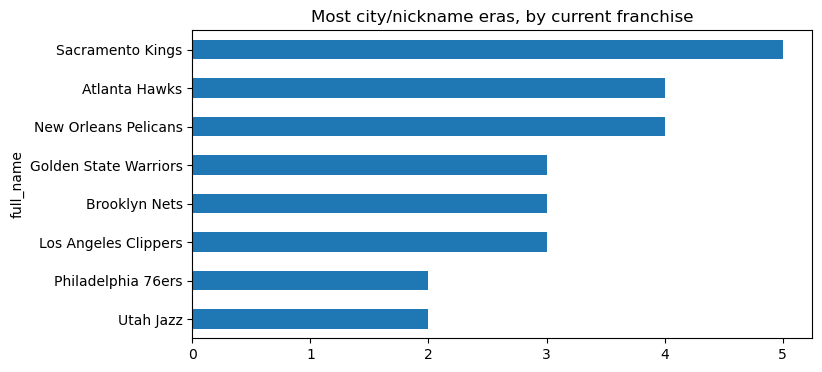

In [36]:
relocation_count = relocation_count_result.DataFrame()
display(relocation_count)
relocation_count.sort_values("city_or_name_eras").plot(
    x="full_name", y="city_or_name_eras", kind="barh", figsize=(8, 4), legend=False,
    title="Most city/nickname eras, by current franchise")

**Insight:** the Kings have had 5 distinct city/nickname eras (Rochester → Cincinnati → Kansas City-Omaha → Kansas City → Sacramento) — the most of any current franchise, which is exactly why Q14's franchise-level totals needed a JOIN to `team` rather than trusting `draft_history`'s own snapshot team names.

### Q19 — Which referees have worked the most nationally-televised games?

**Business question:** a broadcast-partnerships note for Priya — which officials are broadcasters most likely to feature?

In [37]:
%%sql national_tv_officials_result  <<
SELECT o.first_name || ' ' || o.last_name AS official, COUNT(*) AS national_tv_games
FROM officials o
JOIN game_summary g ON o.game_id = g.game_id
WHERE g.natl_tv_broadcaster_abbreviation IS NOT NULL
GROUP BY official
ORDER BY national_tv_games DESC
LIMIT 8

Running query in 'nba'

,official,national_tv_games
0,Scott Foster,500
1,Marc Davis,458
2,Zach Zarba,436
3,James Capers,416
4,Tony Brothers,409
5,Ken Mauer,405
6,Ed Malloy,380
7,Mike Callahan,370


<Axes: title={'center': 'Most nationally-televised games worked, by official'}, ylabel='official'>

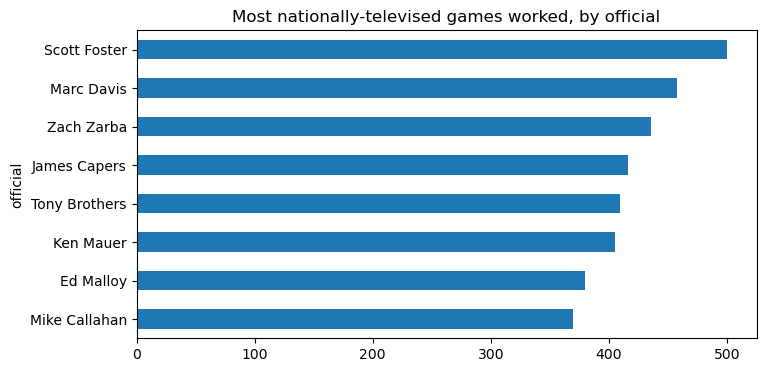

In [38]:
national_tv_officials = national_tv_officials_result.DataFrame()
display(national_tv_officials)
national_tv_officials.sort_values("national_tv_games").plot(
    x="official", y="national_tv_games", kind="barh", figsize=(8, 4), legend=False,
    title="Most nationally-televised games worked, by official")

**Insight:** Scott Foster tops the list at 500 nationally-televised games — a JOIN filtered on a flag-like column (`natl_tv_broadcaster_abbreviation IS NOT NULL`) rather than an equality check, the same shape as filtering on a nullable flag column in Day 02/03.

Priya's last ask is for a person, not a stat.

### Q20 — How many of today's active players entered the league without ever being drafted?

**Business question:** an "underdog story" sidebar — undrafted players who made an NBA roster anyway.

In [39]:
%%sql
SELECT COUNT(*) AS undrafted_active_players
FROM player p
LEFT JOIN draft_history d ON p.id = d.person_id
WHERE d.person_id IS NULL AND p.is_active = 1;

Running query in 'nba'

undrafted_active_players
133


In [40]:
%%sql
SELECT p.full_name
FROM player p
LEFT JOIN draft_history d ON p.id = d.person_id
WHERE d.person_id IS NULL AND p.is_active = 1
ORDER BY p.full_name
LIMIT 10;

Running query in 'nba'

full_name
A.J. Lawson
AJ Green
Alex Caruso
Alondes Williams
Amir Coffey
Anthony Gill
Anthony Lamb
Austin Reaves
Boban Marjanovic
Braxton Key


**Insight:** 133 of the league's 535 active players — about 1 in 4 — went undrafted, including names like Jose Alvarado and Chris Boucher. This is the exact anti-join pattern from Day 03: `LEFT JOIN ... WHERE <right-side key> IS NULL` finds rows on the left with *no* match on the right, here surfacing every player who never appears in `draft_history` at all. Not a bad line to close Priya's piece on.